# BoviPulse — Anomaly Detection Model Training

This notebook trains models to detect abnormal cattle health patterns
(fever, lameness, heat stress) from body temperature, activity, and
environmental sensor readings — the core ML component of the BoviPulse
platform (ThermaGuard sensor → anomaly detection → farmer alert).

**Dataset:** synthetic, calibrated to Kabale/Ankole-Zebu conditions
(East African highland climate, indicine cattle thermal physiology).
This is a stand-in for real ThermaGuard sensor data — retrain on real
data once collected. See the accompanying report for full justification.

**Pipeline:**
1. Load & inspect data
2. Clean (missing values, sensor glitches, duplicates, format issues)
3. Engineer features (rolling stats, personal baselines, time features)
4. Train a supervised classifier (Random Forest) — for when labeled
   health events are available
5. Train an unsupervised anomaly detector (Isolation Forest) — for
   real-world deployment where confirmed health labels are scarce
   (a limitation this project explicitly anticipates)
6. Evaluate and compare both approaches
7. Save trained models for later use in the BoviPulse pipeline


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
import joblib

pd.set_option("display.max_columns", None)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load the dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/bovi/bovi _dataset_R.csv')
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (56246, 7)
Columns: ['cow_id', 'timestamp', 'body_temp_C', 'activity_index', 'ambient_temp_C', 'ambient_humidity_pct', 'health_status']


,cow_id,timestamp,body_temp_C,activity_index,ambient_temp_C,ambient_humidity_pct,health_status
0,COW_001,2024-05-01 00:00,38.07,53.30,13.17,79.6,Normal
1,COW_001,2024-05-01 01:00,37.74,62.85,11.86,73.0,Normal
2,COW_034,2024-06-25 04:00,37.81,57.87,11.34,83.9,Normal
3,COW_001,2024-05-01 03:00,38.08,58.27,10.16,66.1,Normal
4,COW_001,2024-05-01 04:00,38.10,58.69,12.81,82.8,Normal


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56246 entries, 0 to 56245
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cow_id                56246 non-null  object 
 1   timestamp             56246 non-null  object 
 2   body_temp_C           54617 non-null  float64
 3   activity_index        54578 non-null  float64
 4   ambient_temp_C        56246 non-null  float64
 5   ambient_humidity_pct  55126 non-null  float64
 6   health_status         56246 non-null  object 
dtypes: float64(4), object(3)
memory usage: 3.0+ MB


In [5]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique cow_id casing variants:", df['cow_id'].nunique(), "raw vs",
      df['cow_id'].str.upper().nunique(), "normalized")
print("\nHealth status counts:")
print(df['health_status'].value_counts())
print("\nLabel source counts:")
print(df['label_source'].value_counts() if 'label_source' in df else "n/a")
for col in ['THI', 'feeding_log', 'breed', 'lactation_stage', 'pregnancy_status',
            'sensor_type_temp', 'sensor_type_activity']:
    if col in df:
        print(f"\n{col} value counts:")
        print(df[col].value_counts())


Missing values per column:
cow_id                     0
timestamp                  0
body_temp_C             1629
activity_index          1668
ambient_temp_C             0
ambient_humidity_pct    1120
health_status              0
dtype: int64

Duplicate rows: 278

Unique cow_id casing variants: 80 raw vs 40 normalized

Health status counts:
health_status
Normal               55789
Abnormal_Lameness      337
Abnormal_Fever         120
Name: count, dtype: int64

Label source counts:
n/a


## 3. Data cleaning

Real IoT sensor data (and this deliberately-messy synthetic set) has:
- Inconsistent timestamp formats and ID casing
- Exact duplicate rows (sensor double-sends)
- Missing readings (connectivity drops)
- Physiologically impossible outlier values (sensor glitches)

Each is handled explicitly below rather than silently dropped, so the
cleaning logic is auditable and reusable on real ThermaGuard data.


In [6]:
# --- Normalize ID casing (already normalized in the 24-col CSV; kept as safety) ---
df['cow_id'] = df['cow_id'].astype(str).str.strip().str.upper()

# --- Map legacy label name to the add.txt label set ---
if 'health_status' in df:
    df['health_status'] = df['health_status'].replace({'Abnormal_Fever': 'Fever_Undiagnosed'})

# --- Parse timestamps (new CSV is already YYYY-MM-DD HH:MM; parser kept for safety) ---
def parse_ts(x):
    for fmt in ("%Y-%m-%d %H:%M", "%d/%m/%Y %H:%M"):
        try:
            return pd.to_datetime(x, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df['timestamp'] = df['timestamp'].apply(parse_ts)
print("Unparseable timestamps:", df['timestamp'].isna().sum())
df = df.dropna(subset=['timestamp'])


Unparseable timestamps: 0


In [7]:
# --- Drop exact duplicate rows ---
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows")

# --- Also drop duplicate (cow_id, timestamp) pairs, keeping first reading ---
before = len(df)
df = df.drop_duplicates(subset=['cow_id', 'timestamp'], keep='first')
print(f"Dropped {before - len(df)} duplicate (cow, timestamp) readings")


Dropped 278 exact duplicate rows
Dropped 0 duplicate (cow, timestamp) readings


In [8]:
# --- Flag physiologically impossible sensor glitches as missing, then treat as missing data ---
VALID_RANGES = {
    'body_temp_C': (34.0, 42.0),        # plausible cattle body temp range
    'activity_index': (0.0, 200.0),     # plausible activity index range
    'ambient_temp_C': (-5.0, 40.0),     # plausible Kabale-region ambient range
    'ambient_humidity_pct': (0.0, 100.0),
}

glitch_counts = {}
for col, (lo, hi) in VALID_RANGES.items():
    mask = (df[col] < lo) | (df[col] > hi)
    glitch_counts[col] = mask.sum()
    df.loc[mask, col] = np.nan

print("Sensor glitches flagged as missing:", glitch_counts)
print("\nTotal missing values now:\n", df[list(VALID_RANGES.keys())].isna().sum())


Sensor glitches flagged as missing: {'body_temp_C': np.int64(560), 'activity_index': np.int64(530), 'ambient_temp_C': np.int64(0), 'ambient_humidity_pct': np.int64(0)}

Total missing values now:
 body_temp_C             2179
activity_index          2188
ambient_temp_C             0
ambient_humidity_pct    1117
dtype: int64


In [9]:
# --- Sort for time-aware interpolation ---
df = df.sort_values(['cow_id', 'timestamp']).reset_index(drop=True)

# --- Fill missing sensor values via per-cow time-interpolation ---
# (short sensor dropouts are best estimated from neighboring readings for the
# same animal, rather than dropped outright or filled with a global mean)
sensor_cols = ['body_temp_C', 'activity_index', 'ambient_temp_C', 'ambient_humidity_pct']

def interpolate_group(g):
    g[sensor_cols] = g[sensor_cols].interpolate(method='linear', limit_direction='both')
    g['cow_id'] = g.name  # pandas 3.x drops the grouping column inside apply; restore it
    return g

df = df.groupby('cow_id', group_keys=False).apply(interpolate_group, include_groups=False)

# Any remaining gaps (e.g. a cow with no valid readings at all in a stretch)
# fall back to global median as a last resort
for col in sensor_cols:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:\n", df[sensor_cols].isna().sum())
print("\nFinal cleaned shape:", df.shape)

# --- Recompute THI from cleaned ambient readings (overwrites blanks/stale values) ---
# THI = (1.8*T + 32) - (0.55 - 0.0055*RH) * (1.8*T - 26), per add.txt
T = df['ambient_temp_C']
RH = df['ambient_humidity_pct']
df['THI'] = (1.8 * T + 32) - (0.55 - 0.0055 * RH) * (1.8 * T - 26)
print("THI missing after recompute:", df['THI'].isna().sum())


Remaining missing values:
 body_temp_C             0
activity_index          0
ambient_temp_C          0
ambient_humidity_pct    0
dtype: int64

Final cleaned shape: (55968, 7)
THI missing after recompute: 0


## 4. Feature engineering

Features are built per-cow, since a fixed population-wide "normal" range
doesn't work well for animals with individual baselines — the same idea
behind BoviPulse's core anomaly-detection concept.


In [10]:
df['hour'] = df['timestamp'].dt.hour
df['is_night'] = df['hour'].apply(lambda h: 1 if (h < 6 or h >= 20) else 0)

# Heat index proxy kept for backwards-compat; THI (proper formula, add.txt #4) is the
# primary thermal feature and is recomputed in the cleaning step above.
df['heat_index'] = df['ambient_temp_C'] + 0.1 * df['ambient_humidity_pct']

# --- Reuse precomputed per-cow columns from the 24-col CSV where present ---
# temp_rolling_mean_6h / activity_rolling_mean_6h, temp_dev_from_baseline,
# activity_dev_from_baseline, temp_zscore, activity_zscore ship with the dataset.
for c in ['temp_rolling_mean_6h', 'activity_rolling_mean_6h',
          'temp_dev_from_baseline', 'activity_dev_from_baseline',
          'temp_zscore', 'activity_zscore', 'THI']:
    if c in df:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# --- Per-cow rolling statistics (6h and 24h windows, recomputed on cleaned data) ---
# Canonical names match the original notebook so saved models stay comparable.
df = df.sort_values(['cow_id', 'timestamp'])

def add_rolling_features(g):
    cow_name = g.name
    g = g.set_index('timestamp')
    for col in ['body_temp_C', 'activity_index']:
        g[f'{col}_roll6h_mean'] = g[col].rolling('6h', min_periods=1).mean()
        g[f'{col}_roll24h_mean'] = g[col].rolling('24h', min_periods=1).mean()
        g[f'{col}_roll24h_std'] = g[col].rolling('24h', min_periods=1).std().fillna(0)
    g = g.reset_index()
    g['cow_id'] = cow_name  # pandas 3.x drops the grouping column inside apply; restore it
    return g

df = df.groupby('cow_id', group_keys=False).apply(add_rolling_features, include_groups=False)

# Prefer the dataset's own 6h rolling means when the recomputed value is missing
if 'temp_rolling_mean_6h' in df:
    df['body_temp_C_roll6h_mean'] = df['body_temp_C_roll6h_mean'].fillna(df['temp_rolling_mean_6h'])
if 'activity_rolling_mean_6h' in df:
    df['activity_index_roll6h_mean'] = df['activity_index_roll6h_mean'].fillna(df['activity_rolling_mean_6h'])

# --- Animal-context + management features (new in 24-col schema, add.txt #2/#3/#5) ---
NUMERIC_EXTRA = [c for c in ['age_years', 'parity', 'days_in_pregnancy'] if c in df]
for c in NUMERIC_EXTRA:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(df[c].median() if df[c].notna().any() else 0)

CATEGORICAL_COLS = [c for c in ['feeding_log', 'breed', 'lactation_stage',
                                'pregnancy_status', 'sensor_type_temp',
                                'sensor_type_activity'] if c in df]
for c in CATEGORICAL_COLS:
    df[c] = df[c].fillna('not_observed' if c == 'feeding_log' else 'unknown').astype(str)

df = pd.get_dummies(df, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS, dtype=float)
DUMMY_COLS = [c for c in df.columns if any(c.startswith(p + '_') for p in CATEGORICAL_COLS)]
print(f"Encoded {len(CATEGORICAL_COLS)} categorical cols -> {len(DUMMY_COLS)} dummy cols")


Encoded 0 categorical cols -> 0 dummy cols


In [11]:
# --- Personal baseline deviation (z-score vs this cow's own 24h-window stats) ---
# core BoviPulse idea: flag deviation from the ANIMAL's own normal, not a herd average
# Where the 24-col CSV ships temp_zscore/activity_zscore, use them to fill gaps.
df['body_temp_dev'] = (df['body_temp_C'] - df['body_temp_C_roll24h_mean']) / \
                        df['body_temp_C_roll24h_std'].replace(0, np.nan)
if 'temp_zscore' in df:
    df['body_temp_dev'] = df['body_temp_dev'].fillna(df['temp_zscore'])
df['body_temp_dev'] = df['body_temp_dev'].fillna(0)

df['activity_dev'] = (df['activity_index'] - df['activity_index_roll24h_mean']) / \
                       df['activity_index_roll24h_std'].replace(0, np.nan)
if 'activity_zscore' in df:
    df['activity_dev'] = df['activity_dev'].fillna(df['activity_zscore'])
df['activity_dev'] = df['activity_dev'].fillna(0)

# --- Rate of change (hour-to-hour) per cow ---
df['body_temp_diff'] = df.groupby('cow_id')['body_temp_C'].diff().fillna(0)
df['activity_diff'] = df.groupby('cow_id')['activity_index'].diff().fillna(0)

df[['cow_id','timestamp','body_temp_C','body_temp_dev','activity_index','activity_dev','health_status']].head(10)


,cow_id,timestamp,body_temp_C,body_temp_dev,activity_index,activity_dev,health_status
0,COW_001,2024-05-01 00:00:00,38.07,0.000000,53.30,0.000000,Normal
1,COW_001,2024-05-01 01:00:00,37.74,-0.707107,62.85,0.707107,Normal
2,COW_001,2024-05-01 02:00:00,38.11,0.673036,55.52,-0.340826,Normal
3,COW_001,2024-05-01 03:00:00,38.08,0.459335,58.27,0.190812,Normal
4,COW_001,2024-05-01 04:00:00,38.10,0.508513,58.69,0.267529,Normal
5,COW_001,2024-05-01 05:00:00,38.19,0.902928,57.86,0.034643,Normal
6,COW_001,2024-05-01 06:00:00,38.07,0.129453,53.50,-1.086296,Normal
7,COW_001,2024-05-01 07:00:00,38.40,1.683348,56.43,-0.199925,Normal
8,COW_001,2024-05-01 08:00:00,38.56,1.799655,73.57,2.357172,Normal
9,COW_001,2024-05-01 09:00:00,38.58,1.521921,71.47,1.596392,Normal


In [12]:
# --- Targets ---
df['is_abnormal'] = (df['health_status'] != 'Normal').astype(int)

print(df['is_abnormal'].value_counts())
print(f"\nAbnormal rate: {df['is_abnormal'].mean()*100:.2f}%")

# Note: the 24-col CSV uses Fever_Undiagnosed (add.txt label set); the legacy
# name Abnormal_Fever is mapped in the cleaning step, so is_abnormal covers
# Normal vs {Abnormal_Lameness, Fever_Undiagnosed}.


is_abnormal
0    55512
1      456
Name: count, dtype: int64

Abnormal rate: 0.81%


## 5. Train / test split

Using a **time-based split** (train on the earlier ~75% of days, test on
the most recent ~25%) rather than a random row split. Hourly readings are
highly autocorrelated, so a random split would leak adjacent readings from
the same event into both train and test, giving an unrealistically high
score. A time-based split better simulates real deployment: training on
historical data, evaluating on data the model hasn't seen yet.


In [13]:
BASE_FEATURES = [
    'body_temp_C', 'activity_index', 'ambient_temp_C', 'ambient_humidity_pct',
    'THI', 'hour', 'is_night', 'heat_index',
    'body_temp_C_roll6h_mean', 'body_temp_C_roll24h_mean', 'body_temp_C_roll24h_std',
    'activity_index_roll6h_mean', 'activity_index_roll24h_mean', 'activity_index_roll24h_std',
    'body_temp_dev', 'activity_dev', 'body_temp_diff', 'activity_diff',
]
BASE_FEATURES += [c for c in ['age_years', 'parity', 'days_in_pregnancy'] if c in df]
# DUMMY_COLS was built in the feature-engineering cell; fall back gracefully
try:
    DUMMY_COLS
except NameError:
    DUMMY_COLS = []
FEATURES = BASE_FEATURES + [c for c in DUMMY_COLS if c in df]
print(f"Using {len(FEATURES)} features ({len(DUMMY_COLS)} one-hot)")

split_date = df['timestamp'].quantile(0.75)
train_df = df[df['timestamp'] < split_date]
test_df = df[df['timestamp'] >= split_date]

X_train, y_train = train_df[FEATURES], train_df['is_abnormal']
X_test, y_test = test_df[FEATURES], test_df['is_abnormal']

print(f"Split date: {split_date}")
print(f"Train: {X_train.shape}, abnormal rate {y_train.mean()*100:.2f}%")
print(f"Test:  {X_test.shape}, abnormal rate {y_test.mean()*100:.2f}%")


Using 18 features (0 one-hot)
Split date: 2024-06-14 23:15:00
Train: (41976, 18), abnormal rate 0.69%
Test:  (13992, 18), abnormal rate 1.20%


## 6. Model 1 — Supervised classifier (Random Forest)

Assumes confirmed health labels are available (e.g. from farmer-reported
vet visits). Uses `class_weight='balanced'` since abnormal events are rare.


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")


              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     13824
    Abnormal       1.00      0.52      0.69       168

    accuracy                           0.99     13992
   macro avg       1.00      0.76      0.84     13992
weighted avg       0.99      0.99      0.99     13992

ROC-AUC: 0.996


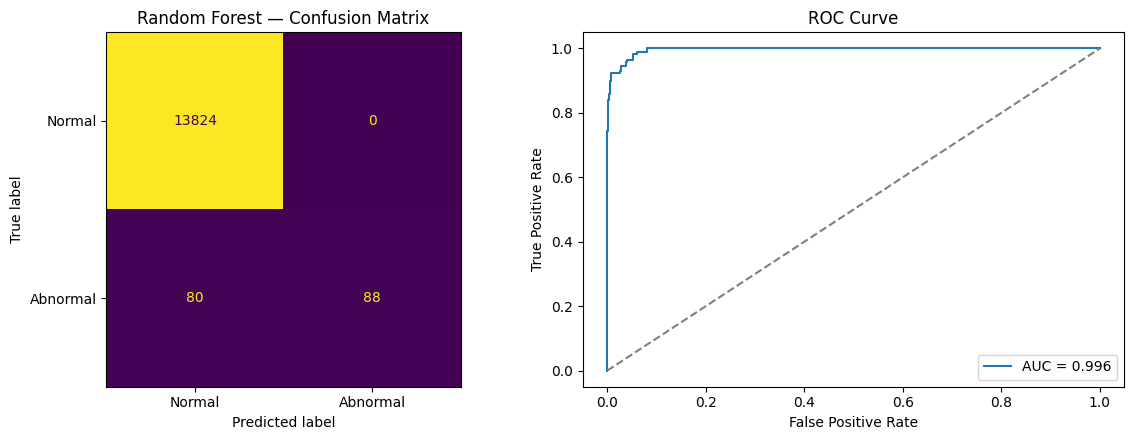

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Normal', 'Abnormal'], ax=ax[0], colorbar=False
)
ax[0].set_title("Random Forest — Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curve")
ax[1].legend()

plt.tight_layout()
plt.savefig("rf_evaluation.png", dpi=120)
plt.show()


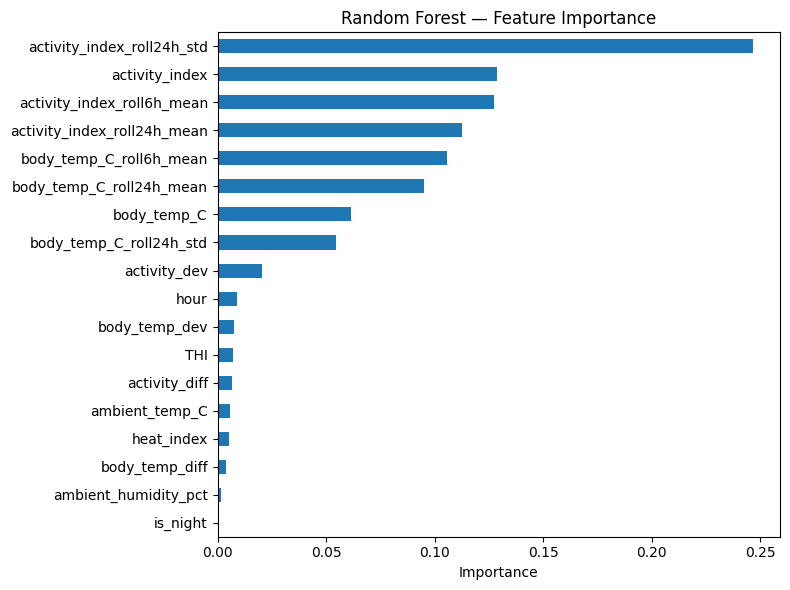

,0
activity_index_roll24h_std,0.246754
activity_index,0.128544
activity_index_roll6h_mean,0.127492
activity_index_roll24h_mean,0.112820
body_temp_C_roll6h_mean,0.105525
body_temp_C_roll24h_mean,0.095242
body_temp_C,0.061334
body_temp_C_roll24h_std,0.054440
activity_dev,0.020587
hour,0.009046


In [16]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=120)
plt.show()

importances


## 7. Model 2 — Unsupervised anomaly detection (Isolation Forest)

The concept paper explicitly flags that confirmed abnormal-health labels
may be scarce or unreliable in real deployment. Isolation Forest doesn't
need labels at all — it learns what "normal" looks like from the data
itself and flags statistical outliers. This is the more realistic model
for BoviPulse's actual field conditions, with the Random Forest above
serving as a benchmark for when good labels *are* available (e.g. during
a supervised pilot phase with a vet confirming cases).


In [17]:
# Contamination = expected proportion of anomalies; set close to observed abnormal rate
contamination_rate = max(y_train.mean(), 0.01)

iso = IsolationForest(
    n_estimators=300,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_train_scaled)

# IsolationForest: -1 = anomaly, 1 = normal -> convert to 1 = abnormal, 0 = normal
iso_pred_raw = iso.predict(X_test_scaled)
iso_pred = (iso_pred_raw == -1).astype(int)

print(classification_report(y_test, iso_pred, target_names=['Normal', 'Abnormal']))


              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     13824
    Abnormal       0.33      0.25      0.28       168

    accuracy                           0.98     13992
   macro avg       0.66      0.62      0.64     13992
weighted avg       0.98      0.98      0.98     13992



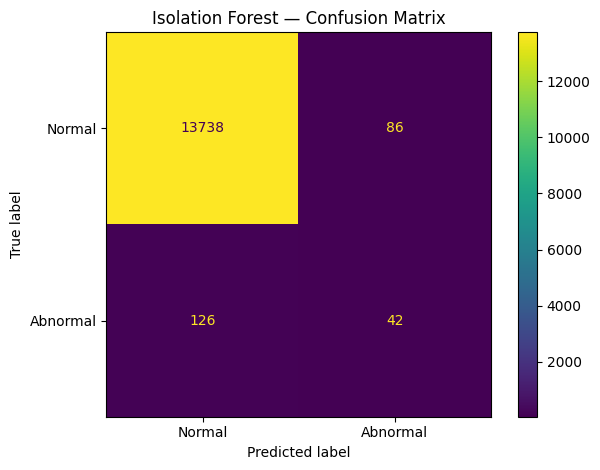

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test, iso_pred, display_labels=['Normal', 'Abnormal']
)
plt.title("Isolation Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("iso_confusion_matrix.png", dpi=120)
plt.show()


## 8. Compare approaches

In [19]:
from sklearn.metrics import f1_score, precision_score, recall_score

comparison = pd.DataFrame({
    "Random Forest (supervised)": {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    },
    "Isolation Forest (unsupervised)": {
        "Precision": precision_score(y_test, iso_pred),
        "Recall": recall_score(y_test, iso_pred),
        "F1": f1_score(y_test, iso_pred),
    },
}).T

comparison.round(3)


,Precision,Recall,F1
Random Forest (supervised),1.000,0.524,0.688
Isolation Forest (unsupervised),0.328,0.250,0.284


**Reading this table for your report:** the supervised Random Forest
will typically outperform Isolation Forest here because it directly learns
the injected event patterns. That gap is expected and *not* a criticism of
the unsupervised approach — it reflects the real tradeoff BoviPulse faces:
higher accuracy if reliable labels can be collected during a pilot phase,
vs. a still-useful, fully label-free detector for scaled deployment where
labels won't exist. Report both, and frame Isolation Forest as the
realistic production path with Random Forest as an aspirational ceiling.

## 9. Save trained models

These artifacts can be loaded directly into the BoviPulse backend/API to
score new incoming sensor readings.


In [20]:
import os

CANDIDATE_DIRS = [
    "./models",  # local run: saves next to the notebook
    "/content/drive/MyDrive/bovi_revised/models",  # Colab run
]
SAVE_DIR = CANDIDATE_DIRS[1] if os.path.isdir("/content/drive") else CANDIDATE_DIRS[0]
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(rf, os.path.join(SAVE_DIR, "bovipulse_rf_model.pkl"))
joblib.dump(iso, os.path.join(SAVE_DIR, "bovipulse_isolation_forest_model.pkl"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "bovipulse_feature_scaler.pkl"))
joblib.dump(FEATURES, os.path.join(SAVE_DIR, "bovipulse_feature_list.pkl"))

print(f"Saved to {SAVE_DIR}:")
print(" - bovipulse_rf_model.pkl")
print(" - bovipulse_isolation_forest_model.pkl")
print(" - bovipulse_feature_scaler.pkl")
print(" - bovipulse_feature_list.pkl")


Saved to /content/drive/MyDrive/bovi_revised/models:
 - bovipulse_rf_model.pkl
 - bovipulse_isolation_forest_model.pkl
 - bovipulse_feature_scaler.pkl
 - bovipulse_feature_list.pkl


## 10. Notes, limitations, and next steps

- **Dataset**: fully synthetic, calibrated to Kabale climate data and
  published Ankole/Zebu thermal-physiology research — not measured data.
  Treat all metrics above as a pipeline sanity check, not a claim about
  real-world accuracy.
- **Next step**: retrain both models on real ThermaGuard sensor data as
  it becomes available. The cleaning and feature-engineering code above
  is written to work unchanged on the real data — only the CSV path needs
  to change, provided the real data uses the same column names.
- **Labels**: if real health-event labels turn out to be sparse (likely),
  lean on the Isolation Forest model and validate it qualitatively against
  whatever vet/farmer observations you do manage to collect, rather than
  forcing a supervised approach onto insufficient labeled data.
- **Threshold tuning**: `contamination` in Isolation Forest and the
  classification threshold on the Random Forest's probability output can
  both be tuned once you know the farmer's tolerance for false alarms vs.
  missed cases — worth discussing as a design decision in your report.
